# Predicting Product Demand in the Global Sports Footwear Market (2018-2026)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
ruta = 'datasets/global_sports_footwear_sales_2018_2026.csv'

In [ ]:
df = pd.read_csv(ruta)
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,1/30/2021,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,10/5/2026,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,11/12/2023,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,8/29/2026,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,11/9/2019,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


## 1. Stastistical Analysis

### 1.1 Numeric analysis

In [ ]:
numeric_attr = ['size', 'base_price_usd', 'discount_percent', 'final_price_usd', 'units_sold', 'revenue_usd', 'customer_rating']

resultado = pd.DataFrame({
    'mean': df[numeric_attr].mean(),
    'median': df[numeric_attr].median(),
    'mode': df[numeric_attr].mode().iloc[0],
    'std': df[numeric_attr].std(),
    'min': df[numeric_attr].min(),
    'max': df[numeric_attr].max()
})

print(resultado)

                        mean  median   mode         std   min    max
size                8.500867     9.0    7.0    1.710896   6.0   11.0
base_price_usd    139.634633   140.0  187.0   46.062549  60.0  219.0
discount_percent   13.332167    10.0    5.0    9.864198   0.0   30.0
final_price_usd   121.029035   119.2  107.1   42.511586  42.0  219.0
units_sold          2.500200     3.0    1.0    1.121149   1.0    4.0
revenue_usd       302.714948   268.2  168.0  179.149272  42.0  876.0
customer_rating     4.001543     4.0    3.4    0.577546   3.0    5.0


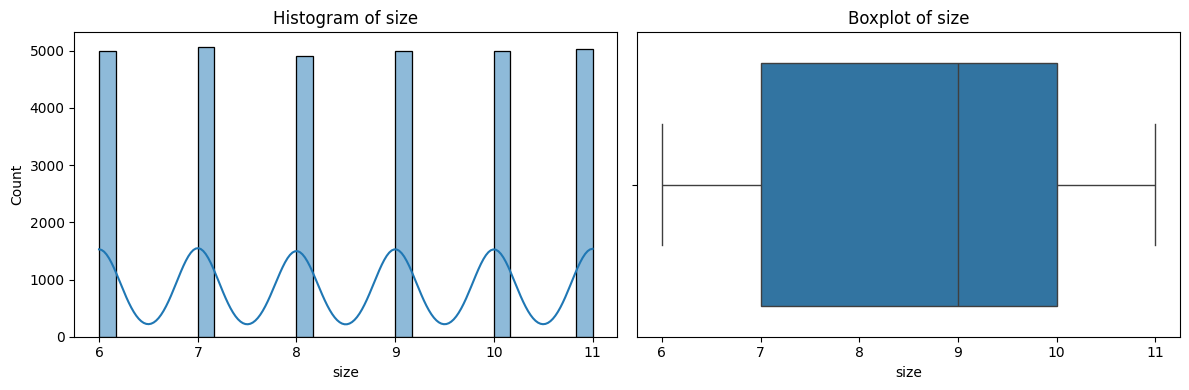

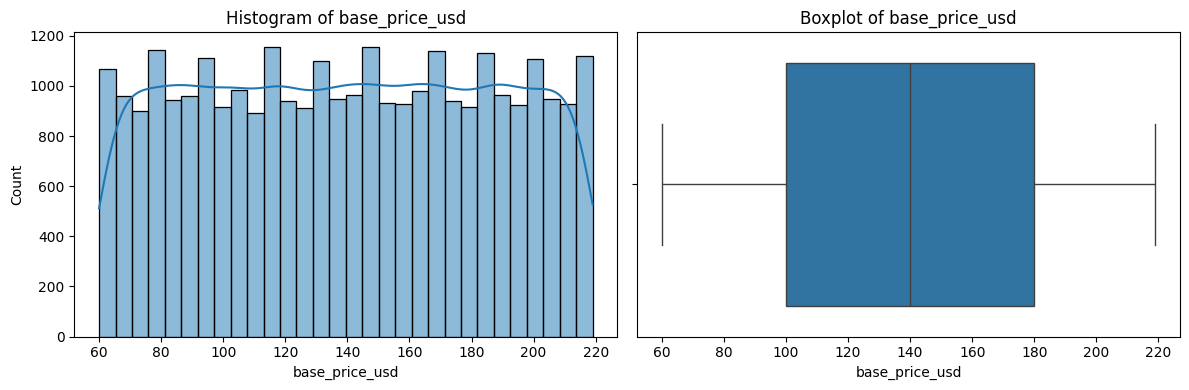

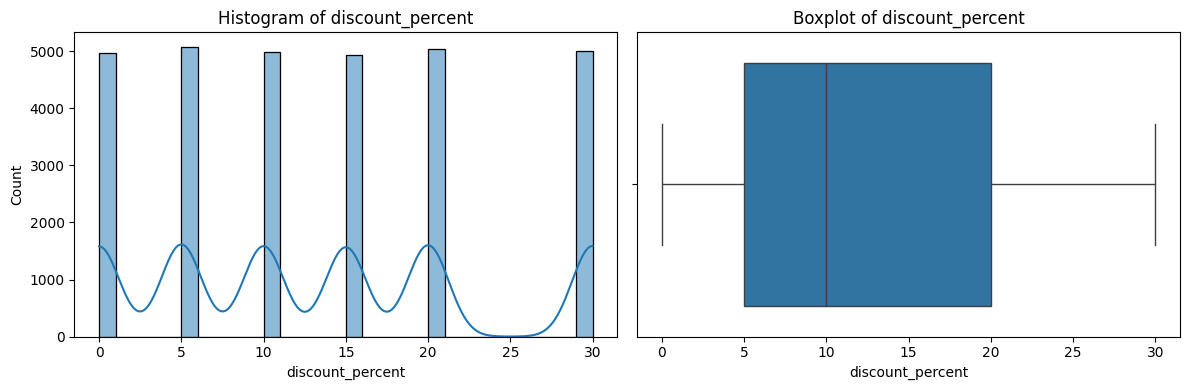

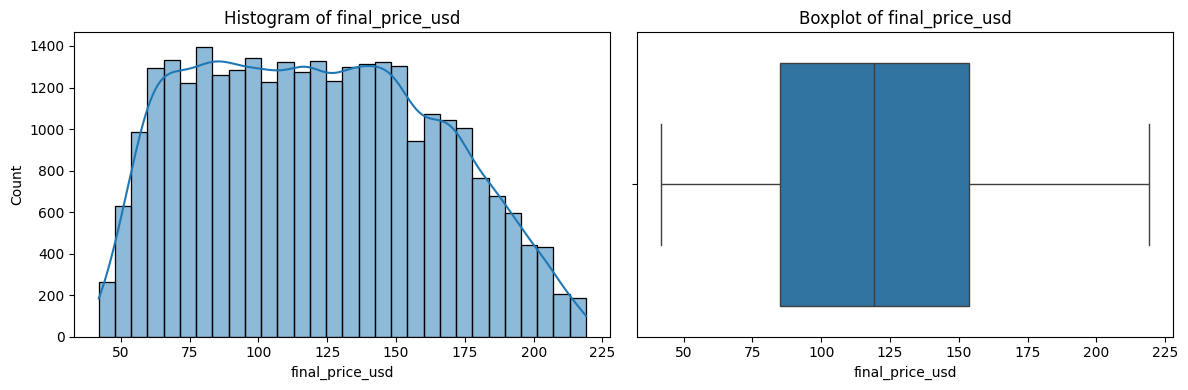

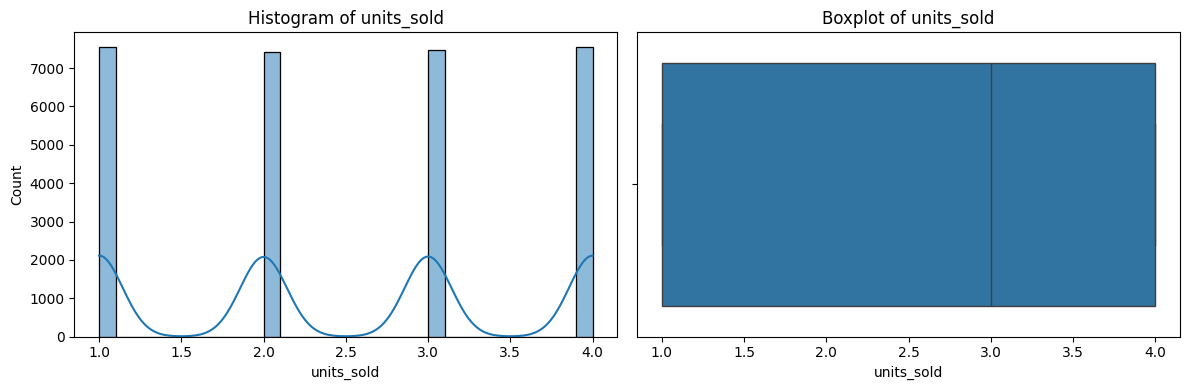

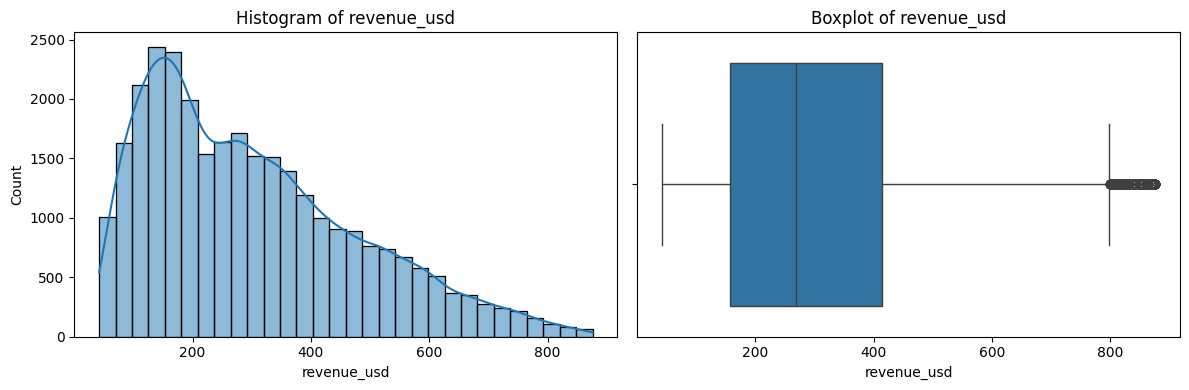

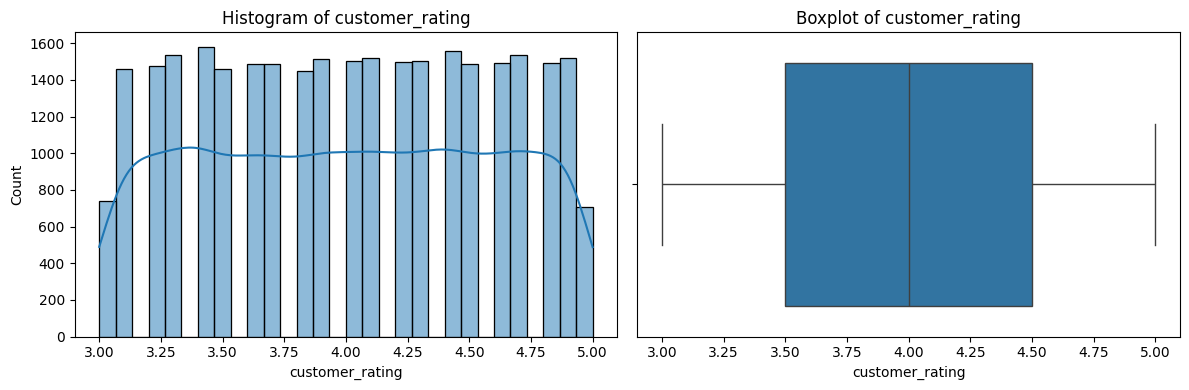

In [ ]:
for col in numeric_attr:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.savefig(f"/content/drive/My Drive/datasets/footwear/{col}_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_7826/2313228841.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='order_date')['units_sold'].sum()


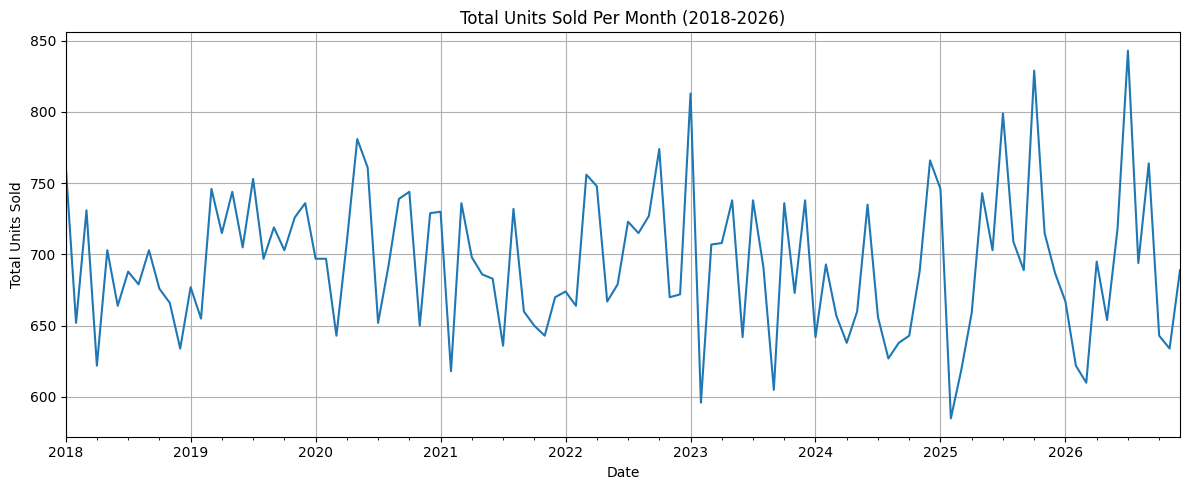

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
# Group by moth and sum units sold
monthly_sales = df.resample('M', on='order_date')['units_sold'].sum()
plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title('Total Units Sold Per Month (2018-2026)')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/sales_over_time.png', dpi=300)
plt.show()

### 1.2. Brand demand trend

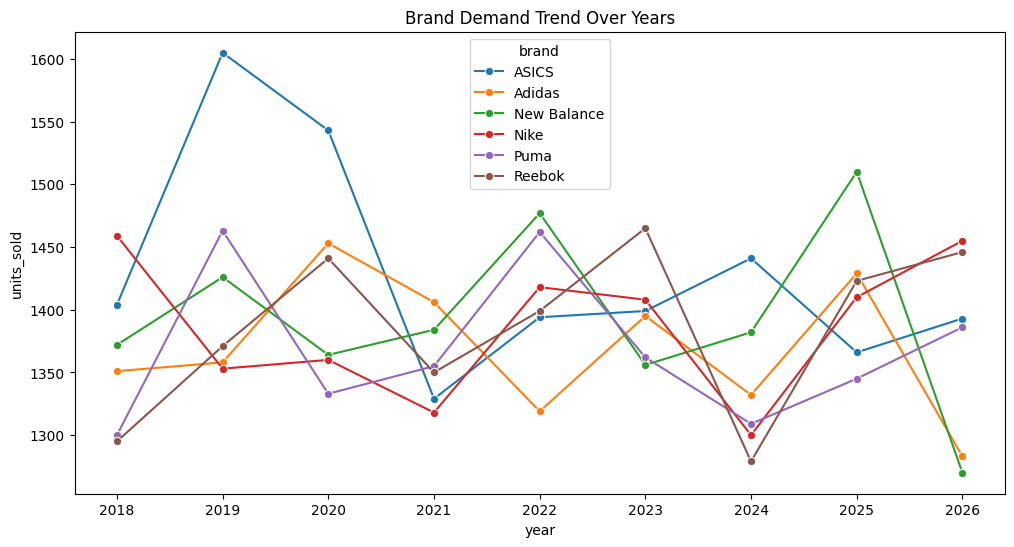

In [ ]:
df = datetimeHandling(df)
brand_trend = df.groupby(['year', 'brand'])['units_sold'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=brand_trend, x='year', y='units_sold', hue='brand', marker='o')
plt.title("Brand Demand Trend Over Years")
plt.show()

### 1.3. Top colors by category

In [ ]:
import plotly.express as px

# Color preferences analysis
color_analysis = df.groupby(['category', 'color']).agg({
    'revenue_usd': 'sum',
    'units_sold': 'sum'
}).reset_index()

# Top colors by category
top_colors = color_analysis.sort_values(['category', 'revenue_usd'], ascending=[True, False])
top_colors = top_colors.groupby('category').head(5)

fig = px.bar(top_colors, x='category', y='revenue_usd', color='color',
             title='Top Colors by Category (Revenue)',
             labels={'revenue_usd': 'Revenue (USD)', 'category': 'Category', 'color': 'Color'},
             barmode='group')
fig.update_layout(height=500)
fig.show()

###  1.4. Customer Analysis

In [ ]:
import plotly.graph_objects as go

# Gender preferences by country
gender_category = df.pivot_table(
    values='units_sold',
    index='country',
    columns='gender',
    aggfunc='sum'
)

fig = go.Figure()
for gender in gender_category.columns:
    fig.add_trace(go.Bar(
        name=gender,
        x=gender_category.index,
        y=gender_category[gender]
    ))

fig.update_layout(
    title='Country Preferences by Gender',
    xaxis_title='Country',
    yaxis_title='Units Sold',
    barmode='group',
    height=500
)
fig.show()

In [ ]:
# Customer rating distribution
rating_dist = df['customer_rating'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Bar(
    x=rating_dist.index,
    y=rating_dist.values,
    marker=dict(
        color=rating_dist.values,
        colorscale='RdYlGn',
        showscale=True
    ),
    text=rating_dist.values,
    textposition='outside'
))

fig.update_layout(
    title='Customer Rating Distribution',
    xaxis_title='Rating',
    yaxis_title='Number of Orders',
    height=500
)
fig.show()

In [ ]:
from plotly.subplots import make_subplots

# Payment method preferences
payment_analysis = df.groupby('payment_method')['units_sold'].sum().reset_index()

payment_analysis.columns = ['Payment_Method', 'Units_Sold']

fig = go.Figure(data=[go.Pie(
    labels=payment_analysis['Payment_Method'],
    values=payment_analysis['Units_Sold'],
    textinfo='label+percent'
)])

fig.update_layout(
    title='Payment Method by Units Sold',
    height=500
)

fig.show()

### 1.5. Distribution of categorical features

In [ ]:
def categorical_summary(df, columnas):
    for col in columnas:
        print(f"\nResumen para atributo: {col}")

        conteo = df[col].value_counts(dropna=False)
        porcentaje = df[col].value_counts(normalize=True, dropna=False) * 100

        tabla = pd.DataFrame({
            "attribute": col,
            "category": conteo.index,
            "count": conteo.values,
            "%": porcentaje.values.round(2)
        })

        print(tabla.to_string(index=False))

In [ ]:
cate_atr = ["brand", "category", "gender", "color", "payment_method", "sales_channel", "country", "customer_income_level"]
categorical_summary(df, cate_atr)


Resumen para atributo: brand
attribute    category  count     %
    brand       ASICS   5132 17.11
    brand      Reebok   5026 16.75
    brand        Nike   5018 16.73
    brand New Balance   4982 16.61
    brand        Puma   4924 16.41
    brand      Adidas   4918 16.39

Resumen para atributo: category
attribute   category  count     %
 category Basketball   6074 20.25
 category  Lifestyle   6059 20.20
 category   Training   6018 20.06
 category    Running   5983 19.94
 category        Gym   5866 19.55

Resumen para atributo: gender
attribute category  count     %
   gender      Men  10075 33.58
   gender    Women  10057 33.52
   gender   Unisex   9868 32.89

Resumen para atributo: color
attribute category  count     %
    color     Grey   6046 20.15
    color      Red   6046 20.15
    color     Blue   5976 19.92
    color    Black   5972 19.91
    color    White   5960 19.87

Resumen para atributo: payment_method
     attribute      category  count     %
payment_method Bank Transf

## 2. Data Preprocessing

### 2.1. Data cleaning
#### 2.1.1. Missing data
There is not missing data

In [ ]:
print(df.isnull().sum())

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
final_price_usd          0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
dtype: int64


## 4. Data transformation

### a. Creation of new attributes
Based on "order_date" split into moth, year and dayofweek.

In [ ]:
def datetimeHandling(df):
  df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
  df["month"] = df["order_date"].dt.month
  df["dayofweek"] = df["order_date"].dt.dayofweek
  df["year"] = df["order_date"].dt.year

  return df.drop(columns=["order_date"])

### b. Feature selection


In [ ]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def splitIntoCategoricalNumerical(df):
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
  numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
  return categorical_cols, numerical_cols

In [ ]:
def dropIrrelevants(df, cols_to_drop):
  return df.drop(columns=cols_to_drop)

## 5. Data mining

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
def splitIntoTrainTest(X,y):
  return train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
def findBestDecisionTree(X_train, y_train):
  param_grid_dt = {
      'max_depth': [5, 10, 15, 20],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 5]
  }

  grid_dt = GridSearchCV(
      DecisionTreeRegressor(random_state=42),
      param_grid_dt,
      cv=5,
      scoring='r2',
      n_jobs=-1
  )

  grid_dt.fit(X_train, y_train)

  best_dt = grid_dt.best_estimator_
  return best_dt

In [ ]:
def findBestRandomForest(X_train, y_train):
  param_grid_rf = {
      'n_estimators': [50, 100],
      'max_depth': [10, None],
  }

  random_rf = RandomizedSearchCV(
      RandomForestRegressor(random_state=42),
      param_distributions=param_grid_rf,
      n_iter=5,
      cv=3,
      scoring='r2',
      n_jobs=2,
      random_state=42,
      verbose=2
  )

  random_rf.fit(X_train, y_train)

  best_rf = random_rf.best_estimator_
  return best_rf

In [ ]:
def findBestGradientBoosting(X_train, y_train):
  param_grid_gb = {
      'n_estimators': [100, 200],
      'learning_rate': [0.01, 0.05, 0.1],
      'max_depth': [3, 5],
      'min_samples_split': [2, 5],
      'min_samples_leaf': [1, 3]
  }

  random_gb = RandomizedSearchCV(
      GradientBoostingRegressor(random_state=42),
      param_distributions=param_grid_gb,
      n_iter=5,
      cv=3,
      scoring='r2',
      n_jobs=2,
      random_state=42,
      verbose=2
  )

  random_gb.fit(X_train, y_train)

  best_gb = random_gb.best_estimator_
  return best_gb

In [ ]:
def predict(bestModel,X_test):
  return bestModel.predict(X_test)

In [ ]:
# Makes predictions according the founded best models for Decision Tree, Random Forest and Gradient Boosting

def makePredictions(best_dt, best_rf, best_gb, X_test):
  return [predict(best_dt,X_test), predict(best_rf,X_test), predict(best_gb,X_test)]

In [ ]:
# According predictions compare performance with the following metrics: r-squared, MAE and MSE
def printResults(predictions, y_test):
  results = pd.DataFrame({
      'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
      'R2': [
          r2_score(y_test, predictions[0]),
          r2_score(y_test, predictions[1]),
          r2_score(y_test, predictions[2])
      ],
      'MAE': [
          mean_absolute_error(y_test, predictions[0]),
          mean_absolute_error(y_test, predictions[1]),
          mean_absolute_error(y_test, predictions[2])
      ],
      'MSE': [
          mean_squared_error(y_test, predictions[0]),
          mean_squared_error(y_test, predictions[1]),
          mean_squared_error(y_test, predictions[2])
      ]
  })

  print(results)

**1. All features using units sold as target**

### Feature selection

#### Pearson correlation coefficient

In [ ]:
df = pd.read_csv(ruta)

In [ ]:
df = datetimeHandling(df)
categ_attr, numeric_attr = splitIntoCategoricalNumerical(df)

In [ ]:
target = "units_sold"

In [ ]:
correlations_1 = df[numeric_attr].corr(method='pearson')[target].drop(target)
print(correlations_1)

size               -0.002659
base_price_usd      0.005353
discount_percent    0.005930
final_price_usd     0.002479
revenue_usd         0.759549
customer_rating    -0.001177
month              -0.000096
dayofweek          -0.006117
year                0.000174
Name: units_sold, dtype: float64


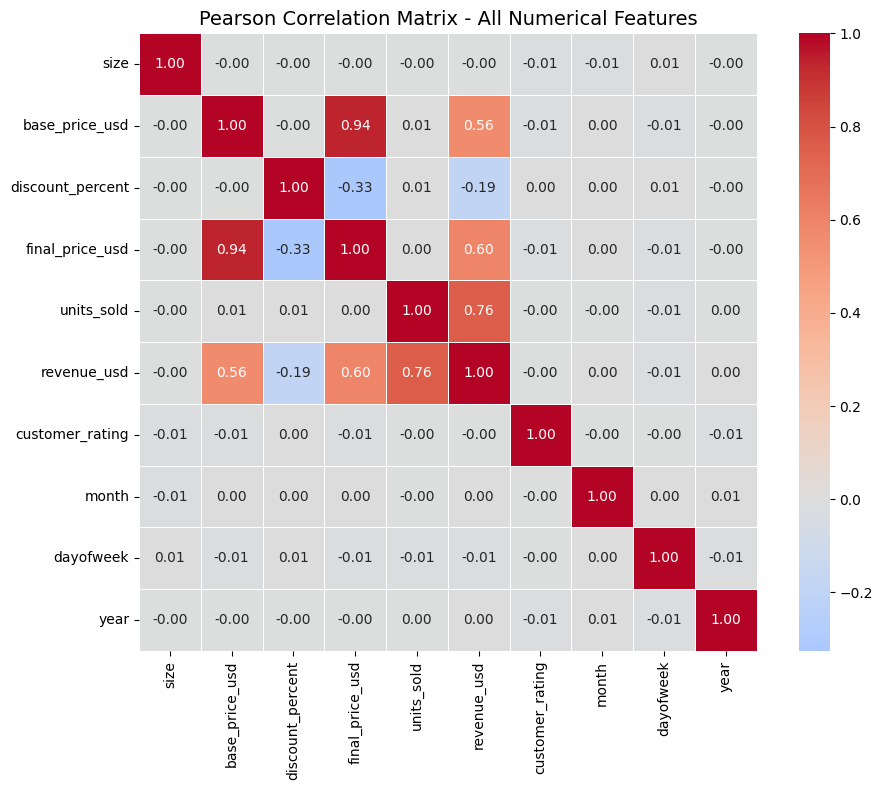

In [ ]:
# Visualize correlation matrix for all numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_attr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Pearson Correlation Matrix - All Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('pearson_correlation_matrix.png', dpi=150)
plt.show()

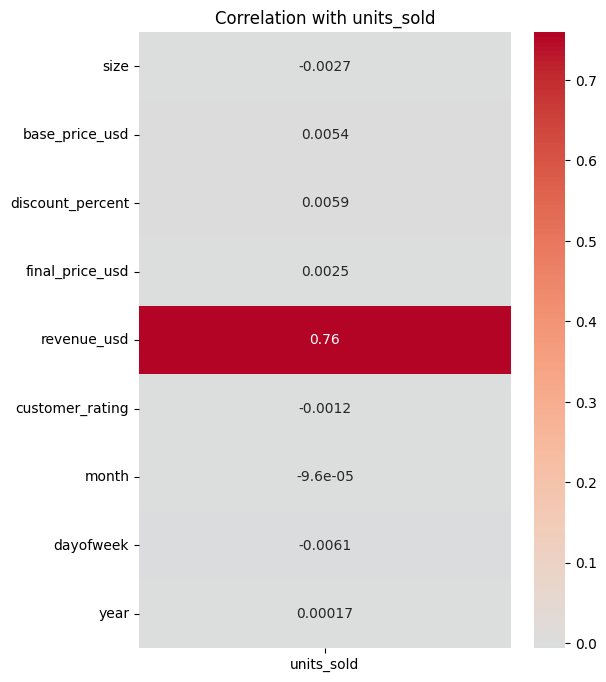

In [ ]:
corr_target = df[numeric_attr].corr()[[target]].drop(index=target)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation with {target}')
plt.show()

#### Mutual information

In [ ]:
# Drop irrelevants attributes and target
#df = dropIrrelevants(df, ['model_name','order_id','revenue_usd','final_price_usd'])
numeric_attr.remove('revenue_usd')
numeric_attr.remove('final_price_usd')
numeric_attr.remove(target)
numeric_attr.remove('base_price_usd')
numeric_attr.remove('customer_rating')
numeric_attr.remove('dayofweek')
numeric_attr.remove('discount_percent')
numeric_attr.remove('size')
numeric_attr.remove('year')
df = dropIrrelevants(df, ['model_name','order_id','revenue_usd', 'final_price_usd','base_price_usd','customer_rating','dayofweek','gender','discount_percent','size','year'])

In [ ]:
# Identify feature types
nominal_cols = ['brand', 'category', 'color', 'payment_method', 'sales_channel','country']
#nominal_cols = ['brand', 'category','gender', 'color', 'payment_method', 'sales_channel','country']
ordinal_cols = ['customer_income_level']

In [ ]:
print(numeric_attr)

['month']


In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
print(X)

             brand    category  color payment_method sales_channel  country  \
0            ASICS     Running  Black           Card  Retail Store  Germany   
1           Reebok   Lifestyle   Grey           Card        Online      USA   
2            ASICS   Lifestyle  Black           Cash  Retail Store    India   
3           Reebok  Basketball  White           Card  Retail Store    India   
4             Nike    Training  Black           Cash        Online      USA   
...            ...         ...    ...            ...           ...      ...   
29995         Puma         Gym   Blue           Card        Online      UAE   
29996       Adidas     Running   Grey           Card        Online       UK   
29997        ASICS  Basketball   Blue         Wallet        Online    India   
29998  New Balance     Running  White         Wallet  Retail Store      USA   
29999         Nike     Running  Black         Wallet  Retail Store      USA   

      customer_income_level  month  
0             

In [ ]:
# create preprocessor to encoding
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(sparse_output=False), nominal_cols),
    ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]), ordinal_cols),
    ('num', 'passthrough', numeric_attr)
])

In [ ]:
# fix and transform features
X_encoded_1 = preprocessor.fit_transform(X)

In [ ]:
# Get feature names after transformation
feature_names = (
    list(preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_cols)) +
    ordinal_cols +
    numeric_attr
)

In [ ]:
# Calculate Mutual Information
mi_scores = mutual_info_regression(X_encoded_1, y, random_state=42)

In [ ]:
# Create DataFrame with results
mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Display results
print("Mutual Information Scores (higher = more predictive):")
print(mi_df)
print(f"\nTotal features: {len(mi_df)}")
print(f"Features with MI > 0: {sum(mi_df['mi_score'] > 0)}")

Mutual Information Scores (higher = more predictive):
                         feature  mi_score
15                    color_Blue  0.008690
30                   country_USA  0.008179
10             category_Training  0.007492
7                   category_Gym  0.005821
16                    color_Grey  0.004516
6            category_Basketball  0.004029
21           payment_method_Cash  0.003397
29                    country_UK  0.003191
23          sales_channel_Online  0.002337
22         payment_method_Wallet  0.002142
18                   color_White  0.001948
31         customer_income_level  0.000905
36                         month  0.000456
24    sales_channel_Retail Store  0.000402
1                   brand_Adidas  0.000360
20           payment_method_Card  0.000170
5                   brand_Reebok  0.000000
3                     brand_Nike  0.000000
2              brand_New Balance  0.000000
0                    brand_ASICS  0.000000
4                     brand_Puma  0.000000


In [ ]:
mi_df['base_feature'] = mi_df['feature'].str.extract(
    r'^(size|country|brand|color|payment_method|category|gender|month|dayofweek|year|discount_percent|final_price_usd|sales_channel|base_price_usd|customer_income_level|customer_rating)'
)

In [ ]:
grouped = mi_df.groupby('base_feature', as_index=False)['mi_score'].sum()
grouped = grouped.sort_values('mi_score', ascending=False)

In [ ]:
print(grouped)

             base_feature  mi_score
2                category  0.017343
3                   color  0.015153
4                 country  0.011370
11         payment_method  0.005709
12          sales_channel  0.002739
5   customer_income_level  0.000905
10                  month  0.000456
1                   brand  0.000360
0          base_price_usd  0.000000
6         customer_rating  0.000000
7               dayofweek  0.000000
9                  gender  0.000000
8        discount_percent  0.000000
13                   size  0.000000
14                   year  0.000000


### Data mining


In [ ]:
X_train, X_test, y_train, y_test = splitIntoTrainTest(X_encoded_1,y)

In [ ]:
best_dt = findBestDecisionTree(X_train, y_train)
print(best_dt)

DecisionTreeRegressor(max_depth=5, random_state=42)


In [ ]:
best_rf = findBestRandomForest(X_train, y_train)
print(best_rf)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomForestRegressor(max_depth=10, random_state=42)


In [ ]:
best_gb = findBestGradientBoosting(X_train, y_train)
print(best_gb)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_split=5,
                          random_state=42)


In [ ]:
printResults(makePredictions(best_dt, best_rf, best_gb, X_test), y_test)

               Model        R2       MAE       MSE
0      Decision Tree -0.003907  1.003063  1.261113
1      Random Forest -0.011245  1.004009  1.270331
2  Gradient Boosting -0.008474  1.004081  1.266850


**2. Numeric features using units_sold as target**

In [ ]:
df = pd.read_csv(ruta)

In [ ]:
df = datetimeHandling(df)
cate_attr, numeric_attr = splitIntoCategoricalNumerical(df)

In [ ]:
target= "units_sold"

In [ ]:
# Drop irrelevant columns
df = dropIrrelevants(df, cate_attr + ['discount_percent','revenue_usd','final_price_usd'])

### Feature selection

#### Pearson correlation coefficient

In [ ]:
numeric_attr.remove('discount_percent')
correlations = df[numeric_attr].corr(method='pearson')[target].drop(target)

print(correlations)

size              -0.001093
base_price_usd     0.562852
final_price_usd    0.595679
units_sold         0.759549
customer_rating   -0.003710
month              0.003326
dayofweek         -0.011926
year               0.001028
Name: revenue_usd, dtype: float64


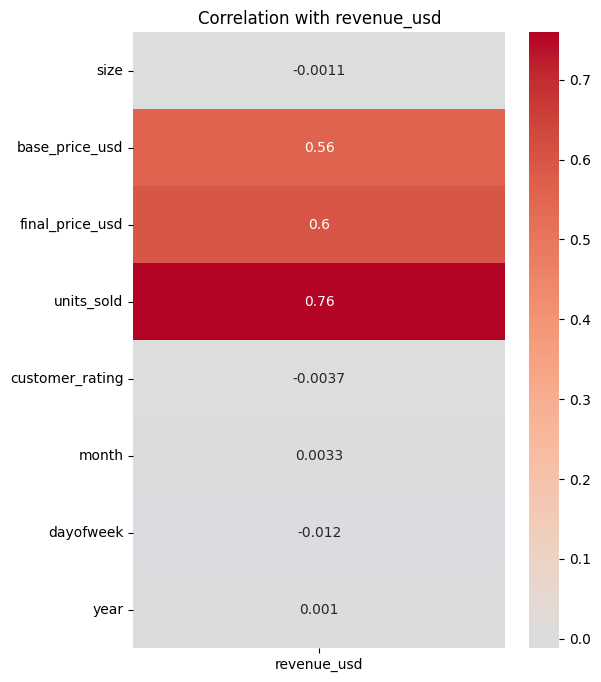

In [ ]:
corr_target = df[numeric_attr].corr()[[target]].drop(index=target)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation with {target}')
plt.show()

#### Mutual information

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
numeric_attr.remove(target)
print(numeric_attr)

['size', 'base_price_usd', 'discount_percent', 'final_price_usd', 'revenue_usd', 'customer_rating', 'month', 'dayofweek', 'year']


In [ ]:
numeric_attr.remove('revenue_usd')
numeric_attr.remove('final_price_usd')


In [ ]:
print(numeric_attr)

['size', 'base_price_usd', 'discount_percent', 'customer_rating', 'month', 'dayofweek', 'year']


In [ ]:
mi = mutual_info_regression(X_scaled, y, random_state=42)

mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi
}).sort_values('mi_score', ascending=False)

print(mi_df)

           feature  mi_score
3            month  0.004097
5             year  0.002244
0             size  0.002131
2  customer_rating  0.000039
1   base_price_usd  0.000000
4        dayofweek  0.000000


In [ ]:
k = 5
top_features = mi_df.head(k)['feature']
X_selected = X[top_features]

In [ ]:
print(top_features)

3              month
5               year
0               size
2    customer_rating
1     base_price_usd
Name: feature, dtype: object


In [ ]:
X_selected = X

In [ ]:
print(X_selected)

       size  base_price_usd  customer_rating  month  dayofweek  year
0         8             162              4.6      1          5  2021
1         8              80              3.9     10          0  2026
2         8             176              3.0     11          6  2023
3         7              61              3.4      8          5  2026
4        11              80              3.0     11          5  2019
...     ...             ...              ...    ...        ...   ...
29995     6             140              4.3      5          0  2018
29996     9             113              3.5      4          5  2018
29997    11             130              4.4      2          1  2026
29998    11             186              3.9      2          2  2024
29999     8              72              4.0      6          3  2020

[30000 rows x 6 columns]


### Data mining

In [ ]:
X_train, X_test, y_train, y_test = splitIntoTrainTest(X_selected,y)

In [ ]:
best_dt = findBestDecisionTree(X_train, y_train)
print(best_dt)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)


In [ ]:
best_rf = findBestRandomForest(X_train, y_train)
print(best_rf)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomForestRegressor(max_depth=10, random_state=42)


In [ ]:
best_gb = findBestGradientBoosting(X_train, y_train)
print(best_gb)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_split=5,
                          random_state=42)


In [ ]:
printResults(makePredictions(best_dt, best_rf, best_gb, X_test), y_test)

               Model        R2       MAE       MSE
0      Decision Tree -0.007564  1.003361  1.265707
1      Random Forest -0.007957  1.002845  1.266201
2  Gradient Boosting -0.004274  1.001945  1.261575


**3. Categorical features using revenue as target**

In [ ]:
df = pd.read_csv(ruta)

In [ ]:
target= "revenue_usd"

In [ ]:
important_attr = ['gender', 'country','brand','category', 'sales_channel',target]
df = df[important_attr]

In [ ]:
X = df.drop(columns=[target])
y = df[target]
important_attr.remove(target)

#### Mutual information

In [ ]:
# create preprocessor to encoding
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(sparse_output=False), important_attr)
])

In [ ]:
# fix and transform features
X_encoded = preprocessor.fit_transform(X)

In [ ]:
# Get feature names after transformation
feature_names = (
    list(preprocessor.named_transformers_['onehot'].get_feature_names_out(important_attr))
)

In [ ]:
# Calculate Mutual Information
mi_scores = mutual_info_regression(X_encoded, y, random_state=42)

In [ ]:
# Create DataFrame with results
mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

In [ ]:
mi_df['base_feature'] = mi_df['feature'].str.extract(
    r'^(country|brand|color|payment_method|category|gender|sales_channel|customer_income_level)'
)

In [ ]:
grouped = mi_df.groupby('base_feature', as_index=False)['mi_score'].sum()
grouped = grouped.sort_values('mi_score', ascending=False)

In [ ]:
print(grouped)

    base_feature  mi_score
2        country  0.020585
0          brand  0.006057
3         gender  0.004618
4  sales_channel  0.001340
1       category  0.001338


### Data mining

In [ ]:
X_train, X_test, y_train, y_test = splitIntoTrainTest(X_encoded,y)

In [ ]:
best_dt = findBestDecisionTree(X_train, y_train)
print(best_dt)

DecisionTreeRegressor(max_depth=5, random_state=42)


In [ ]:
best_rf = findBestRandomForest(X_train, y_train)
print(best_rf)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomForestRegressor(max_depth=10, random_state=42)


In [ ]:
best_gb = findBestGradientBoosting(X_train, y_train)
print(best_gb)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_split=5,
                          random_state=42)


In [ ]:
printResults(makePredictions(best_rf, best_rf, best_gb, X_test), y_test)

               Model        R2         MAE           MSE
0      Decision Tree -0.012606  148.427416  32623.731936
1      Random Forest -0.012606  148.427416  32623.731936
2  Gradient Boosting -0.003484  147.786345  32329.836413


**3. Categorical features using units_sold as target**

In [ ]:
df = pd.read_csv(ruta)

In [ ]:
target= "units_sold"

In [ ]:
important_attr = ['gender', 'country','brand','category', 'sales_channel',target]
df = df[important_attr]

In [ ]:
X = df.drop(columns=[target])
y = df[target]
important_attr.remove(target)

#### Mutual information

In [ ]:
# create preprocessor to encoding
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(sparse_output=False), important_attr)
])

In [ ]:
# fix and transform features
X_encoded = preprocessor.fit_transform(X)

In [ ]:
# Get feature names after transformation
feature_names = (
    list(preprocessor.named_transformers_['onehot'].get_feature_names_out(important_attr))
)

In [ ]:
# Calculate Mutual Information
mi_scores = mutual_info_regression(X_encoded, y, random_state=42)

In [ ]:
# Create DataFrame with results
mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

In [ ]:
mi_df['base_feature'] = mi_df['feature'].str.extract(
    r'^(country|brand|color|payment_method|category|gender|sales_channel|customer_income_level)'
)

In [ ]:
grouped = mi_df.groupby('base_feature', as_index=False)['mi_score'].sum()
grouped = grouped.sort_values('mi_score', ascending=False)

In [ ]:
print(grouped)

    base_feature  mi_score
0          brand  0.032902
2        country  0.007341
1       category  0.004222
3         gender  0.000000
4  sales_channel  0.000000


### Data mining

In [ ]:
X_train, X_test, y_train, y_test = splitIntoTrainTest(X_encoded,y)

In [ ]:
best_dt = findBestDecisionTree(X_train, y_train)
print(best_dt)

DecisionTreeRegressor(max_depth=5, random_state=42)


In [ ]:
best_rf = findBestRandomForest(X_train, y_train)
print(best_rf)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomForestRegressor(max_depth=10, random_state=42)


In [ ]:
best_gb = findBestGradientBoosting(X_train, y_train)
print(best_gb)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_split=5,
                          random_state=42)


In [ ]:
printResults(makePredictions(best_dt, best_rf, best_gb, X_test), y_test)

               Model        R2       MAE       MSE
0      Decision Tree -0.002182  1.002711  1.258946
1      Random Forest -0.011280  1.002084  1.270375
2  Gradient Boosting -0.001987  1.001815  1.258701


### Feature reduction
#### PCA

In [ ]:
features = [
    'size',
    'base_price_usd',
    'discount_percent',
    'customer_rating'
]

X = df[features]

In [ ]:
y = df['units_sold']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### 2 components

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)

pca_df['units_sold'] = y.values

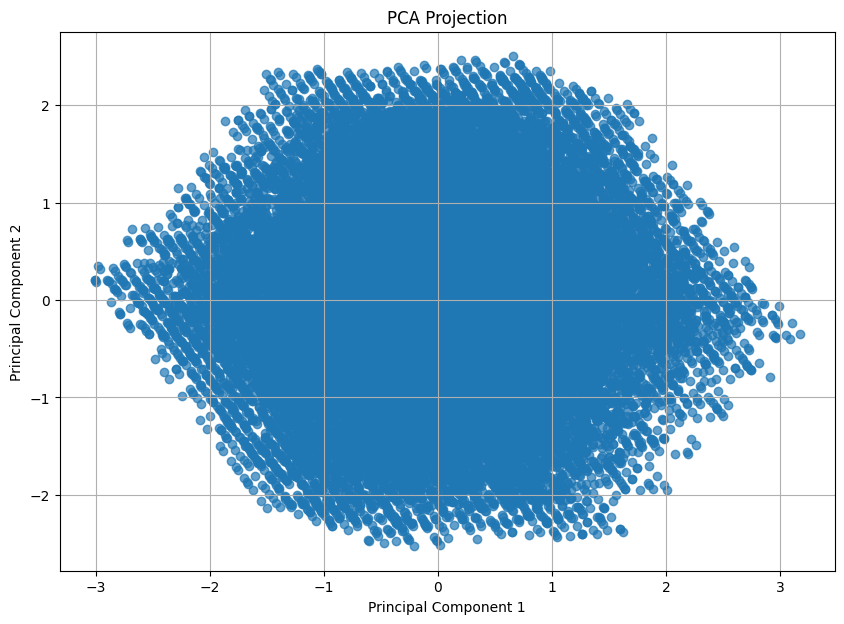

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')

plt.grid(True)

plt.show()

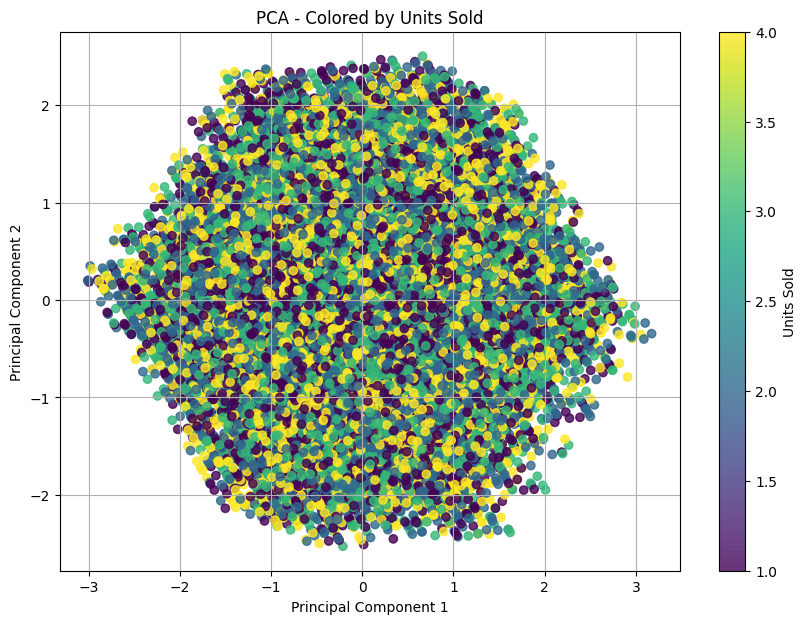

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['units_sold'],
    cmap='viridis',
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('PCA - Colored by Units Sold')

plt.colorbar(scatter, label='Units Sold')

plt.grid(True)

plt.show()

In [ ]:
print(pca.explained_variance_ratio_)

[0.25216057 0.25018146]


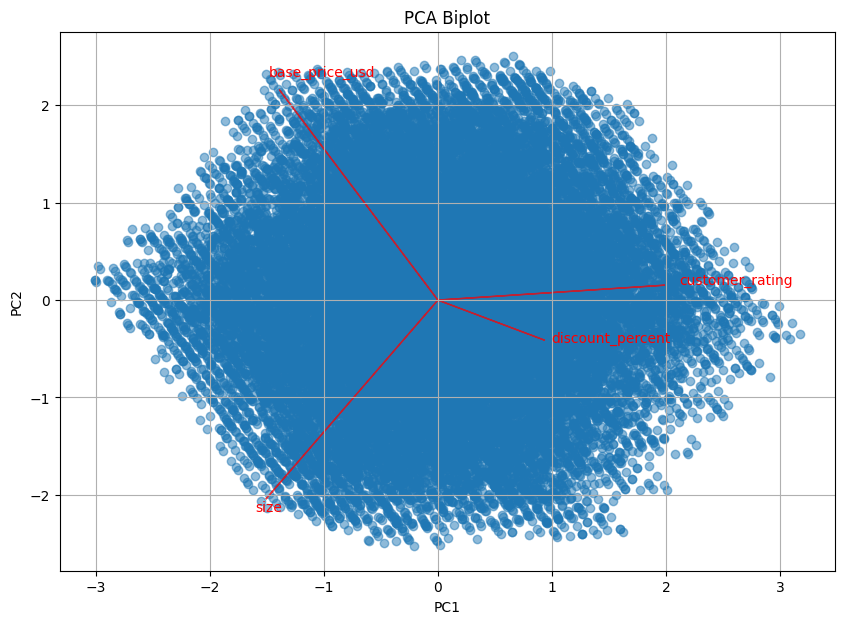

In [ ]:
loadings = pca.components_.T

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

for i, feature in enumerate(features):

    plt.arrow(
        0, 0,
        loadings[i,0]*3,
        loadings[i,1]*3,
        color='red',
        alpha=0.7
    )

    plt.text(
        loadings[i,0]*3.2,
        loadings[i,1]*3.2,
        feature,
        color='red'
    )

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('PCA Biplot')

plt.grid(True)

plt.show()

In [ ]:
print(sum(pca.explained_variance_ratio_))

0.5023420344551788


In [ ]:
X_selected_scaled = StandardScaler().fit_transform(X_encoded)

In [ ]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

print(cumulative_variance)

[0.25216057 0.50234203 0.7522197  1.        ]


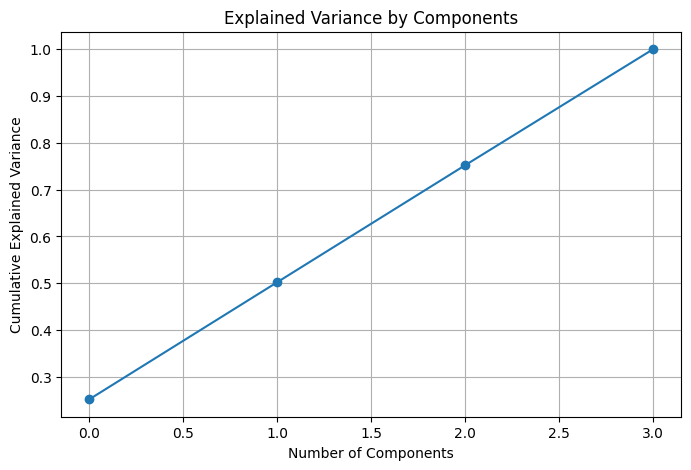

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('Explained Variance by Components')

plt.grid(True)

plt.show()

### 3 components

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca_3 = pca.fit_transform(X_scaled)

In [ ]:
pca3_df = pd.DataFrame(
    X_pca_3,
    columns=['PC1', 'PC2', 'PC3']
)

pca3_df['units_sold'] = y.values

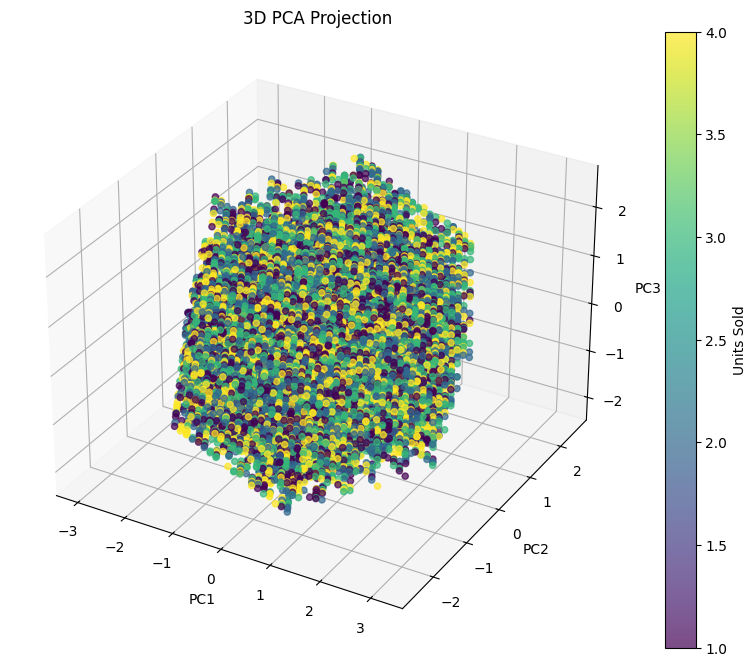

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca3_df['PC1'],
    pca3_df['PC2'],
    pca3_df['PC3'],
    c=pca3_df['units_sold'],
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.title('3D PCA Projection')

fig.colorbar(scatter, label='Units Sold')

plt.show()

In [ ]:
print(pca.explained_variance_ratio_)

[0.25216057 0.25018146 0.24987767]


In [ ]:
print(sum(pca.explained_variance_ratio_))

0.7522197013272521
